# Gradient Descent Implementation

[![Twitter Handle](https://img.shields.io/badge/Twitter-@gaohongnan-blue?style=social&logo=twitter)](https://twitter.com/gaohongnan)
[![LinkedIn Profile](https://img.shields.io/badge/@gaohongnan-blue?style=social&logo=linkedin)](https://linkedin.com/in/gao-hongnan)
[![GitHub Profile](https://img.shields.io/badge/GitHub-gao--hongnan-lightgrey?style=social&logo=github)](https://github.com/gao-hongnan)
![Tag](https://img.shields.io/badge/Tag-Organized_Chaos-orange)

```{contents}
:local:
```

We implement **batch gradient descent** from scratch and use it to minimize two
toy objectives, following the treatment in Dive into Deep Learning, Chapter
12.3 {cite}`zhang2021dive` — rewritten here to depend only on NumPy, PyTorch
and Matplotlib.

In [1]:
from abc import ABC, abstractmethod
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch

## Optimizer Base Class

An optimizer owns the objective $f$, its gradient $\nabla f$, and a learning
rate $\eta$. Concrete optimizers implement `step`, which maps the current
weights to the next iterate.

In [2]:
class Optimizer(ABC):
    """Base class for iterative first-order optimizers."""

    def __init__(
        self,
        f: Callable[[float | np.ndarray], float | np.ndarray],
        grad_f: Callable[[float | np.ndarray], float | np.ndarray],
        lr: float,
    ) -> None:
        self.f = f
        self.grad_f = grad_f
        self.lr = lr

    @abstractmethod
    def step(self, weights: float | np.ndarray) -> float | np.ndarray:
        """Advance one iteration from ``weights`` and return the next iterate."""

## Gradient Descent

Batch gradient descent implements the update rule

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \nabla f\left(\mathbf{w}^{(t)}\right)
$$

and records every iterate so that we can visualize the optimization
trajectory.

In [3]:
class GradientDescent(Optimizer):
    """Batch gradient descent with a constant learning rate."""

    def __init__(
        self,
        f: Callable[[float | np.ndarray], float | np.ndarray],
        grad_f: Callable[[float | np.ndarray], float | np.ndarray],
        lr: float,
    ) -> None:
        super().__init__(f, grad_f, lr)
        self.weights_history: list[float | np.ndarray] = []

    def step(self, weights: float | np.ndarray) -> float | np.ndarray:
        if not self.weights_history:
            self.weights_history.append(weights)
        new_weights = weights - self.lr * self.grad_f(weights)
        self.weights_history.append(new_weights)
        return new_weights

## One-Dimensional Example

Minimize $f(w) = w^2$, whose gradient is $f'(w) = 2w$. Starting from
$w^{(0)} = 10$ with $\eta = 0.2$, each update is
$w^{(t+1)} = w^{(t)} - 0.4 w^{(t)} = 0.6 w^{(t)}$, so the iterates contract
toward the minimizer $w^\star = 0$ by a factor of $0.6$ per step.

In [4]:
def f(w: float) -> float:
    """Objective f(w) = w^2."""
    return w**2


def grad_f(w: float) -> float:
    """Gradient f'(w) = 2w."""
    return 2 * w


batch_gd = GradientDescent(f=f, grad_f=grad_f, lr=0.2)

weights = 10.0
for _ in range(10):
    weights = batch_gd.step(weights)

print([round(w, 4) for w in batch_gd.weights_history])

[10.0, 6.0, 3.6, 2.16, 1.296, 0.7776, 0.4666, 0.2799, 0.168, 0.1008, 0.0605]


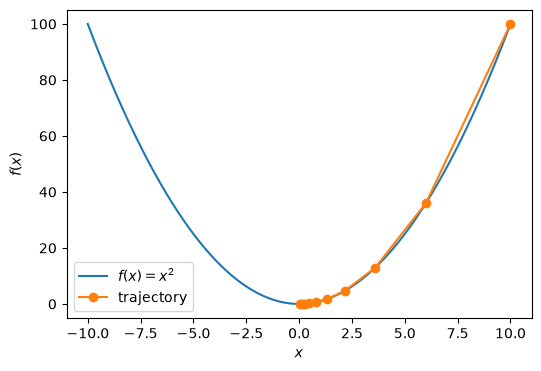

In [5]:
def show_trace(f: Callable[[np.ndarray], np.ndarray], results: list[float]) -> None:
    """Plot f and the optimization trajectory over it."""
    bound = max(abs(min(results)), abs(max(results)))
    line = np.arange(-bound, bound, 0.01)
    _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(line, f(line), label="$f(x) = x^2$")
    ax.plot(results, [f(x) for x in results], "-o", color="#ff7f0e", label="trajectory")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    ax.legend()
    plt.show()


show_trace(f, batch_gd.weights_history)

## Two-Dimensional Example

Next, minimize

$$
f(\mathbf{w}) = w_1^2 + 2 w_2^2, \qquad \nabla f(\mathbf{w}) = \begin{bmatrix} 2 w_1 \\ 4 w_2 \end{bmatrix}
$$

starting from $\mathbf{w}^{(0)} = (-5, -2)$ with $\eta = 0.1$. The two
coordinates decay at different rates because the curvature along $w_2$ is
twice that along $w_1$.

In [6]:
def f_2d(w: np.ndarray) -> np.ndarray:
    """Objective f(w) = w1^2 + 2 * w2^2."""
    return w[0] ** 2 + 2 * w[1] ** 2


def grad_f_2d(w: np.ndarray) -> np.ndarray:
    """Gradient [2 * w1, 4 * w2]."""
    return np.asarray([2 * w[0], 4 * w[1]])


batch_gd_2d = GradientDescent(f=f_2d, grad_f=grad_f_2d, lr=0.1)

weights_2d = np.asarray([-5.0, -2.0])
for _ in range(20):
    weights_2d = batch_gd_2d.step(weights_2d)

weights_2d

array([-5.76460752e-02, -7.31231688e-05])

### Verifying the Gradient with Automatic Differentiation

The original notebook used the `autograd` package to differentiate the
objective; the modern equivalent is `torch.func.grad`, which differentiates a
function written with PyTorch operations. We use it to confirm our
hand-derived gradient.

In [7]:
grad_f_2d_autodiff = torch.func.grad(lambda w: w[0] ** 2 + 2 * w[1] ** 2)

point = torch.tensor([-5.0, -2.0])
manual = grad_f_2d(point.numpy())
automatic = grad_f_2d_autodiff(point).numpy()
print(f"manual:    {manual}")
print(f"automatic: {automatic}")
assert np.allclose(manual, automatic)

manual:    [-10.  -8.]
automatic: [-10.  -8.]


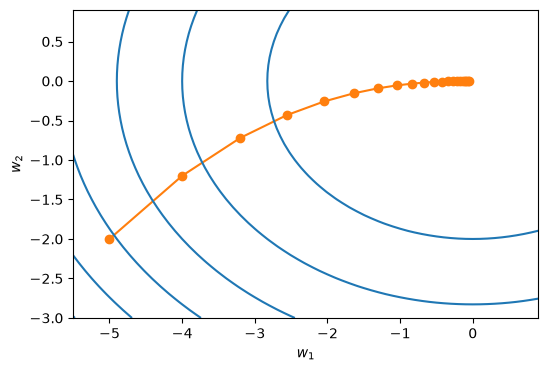

In [8]:
def show_trace_2d(f: Callable[[np.ndarray], np.ndarray], results: list[np.ndarray]) -> None:
    """Plot the level sets of f and the optimization trajectory."""
    trajectory = np.stack(results)
    _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(trajectory[:, 0], trajectory[:, 1], "-o", color="#ff7f0e")
    x1, x2 = np.meshgrid(
        np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1), indexing="ij"
    )
    ax.contour(x1, x2, f(np.stack([x1, x2])), colors="#1f77b4")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    plt.show()


show_trace_2d(f_2d, batch_gd_2d.weights_history)